# 9주차: 자연어 처리(NLP) 심화 실습

본 실습에서는 자연어 처리의 두 가지 실무 심화 기법을 다룹니다:
1. **텍스트 네트워크 분석 (Semantic Network Analysis)**: 단어 간 동시 출현(Co-occurrence) 관계를 구조적으로 분석하고 시각화합니다.
2. **머신러닝 기반 감성 분석 (Sentiment Analysis)**: NSMC(Naver Movie Sentiment Corpus) 데이터와 배달의민족 리뷰 데이터를 활용하여 긍정/부정 감성 분류 모델을 구축하고 실무에 적용합니다.

## 1. 환경 설정 및 필수 라이브러리 임포트

시각화를 위한 한글 폰트 설정 및 `networkx`, `kiwipiepy`, `pandera`, `scikit-learn` 등을 임포트합니다.

In [ ]:
import re
import numpy as np
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
import platform
from collections import Counter, defaultdict
from itertools import combinations
from kiwipiepy import Kiwi
import pandera as pa
from pandera.typing import Series
from config import CONTENT_DIR
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import lightgbm as lgb
import warnings
from tqdm import tqdm
from konlpy.tag import Okt
from apyori import apriori

warnings.filterwarnings('ignore')

# 한글 폰트 설정 (OS 환경별 대응)
if platform.system() == 'Darwin':  # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':  # Windows
    plt.rc('font', family='Malgun Gothic')
else:  # Linux (Ubuntu, Colab 등)
    plt.rc('font', family='NanumGothic')

plt.rc('axes', unicode_minus=False)
print("환경 설정 완료!")

환경 설정 완료!


## 2. 텍스트 네트워크 분석 (Semantic Network Analysis)

단어가 문장이나 리뷰 내에서 동시에 출현하는 빈도를 기반으로 가중 네트워크를 생성합니다.

In [2]:
# 샘플 리뷰 데이터셋정의 (배달 앱 관련 가상 데이터)
sample_reviews = [
    "배달이 너무 늦어서 음식이 다 식어서 왔어요. 정말 화가 납니다.",
    "주문하고 한 시간이나 기다렸는데 취소도 안 되고 고객센터 전화도 안 받네요.",
    "여기 진짜 맛집이네요! 양도 많고 배달도 엄청 빨라요. 강력 추천!",
    "가격 대비 양이 너무 적어요. 맛은 있는데 아쉽습니다.",
    "배달원 분이 친절하시고 포장도 꼼꼼하게 잘 왔습니다.",
    "쿠폰 혜택이 좋아서 주문했는데 앱이 자꾸 튕겨서 결제가 안 되네요.",
    "주문 내역 조회가 안 되고 결제 에러가 나서 불편해요.",
    "고객센터 연결이 너무 지연되네요. 상담사가 전화를 안 받아요."
]

# 형태소 분석 및 화이트리스트 기반 품사 필터링 함수 (Kiwi 사용)
kiwi = Kiwi()
allowed_tags = {'NNG', 'NNP', 'XR', 'VV', 'VA'}  # 명사, 어근, 동사, 형용사
stopwords = {'하다', '되다', '받다', '나다', '오다', '있다', '없다'}

def extract_keywords(text):
    # 한글 및 공백 제외 특수문자 정제
    cleaned = re.sub(r'[^가-힣\s]', '', text)
    tokens = kiwi.tokenize(cleaned)
    keywords = []
    for t in tokens:
        if t.tag in allowed_tags and t.form not in stopwords:
            # 동사/형용사는 어간 원형 사용
            keywords.append(t.form)
    return keywords

# 키워드 추출 확인
for i, review in enumerate(sample_reviews):
    print(f"리뷰 {i+1}: {review}")
    print(f"추출된 키워드: {extract_keywords(review)}")
    print("-" * 50)

리뷰 1: 배달이 너무 늦어서 음식이 다 식어서 왔어요. 정말 화가 납니다.
추출된 키워드: ['배달', '늦', '음식', '식', '오', '화', '나']
--------------------------------------------------
리뷰 2: 주문하고 한 시간이나 기다렸는데 취소도 안 되고 고객센터 전화도 안 받네요.
추출된 키워드: ['주문', '시간', '기다리', '취소', '되', '고객', '센터', '전화']
--------------------------------------------------
리뷰 3: 여기 진짜 맛집이네요! 양도 많고 배달도 엄청 빨라요. 강력 추천!
추출된 키워드: ['맛집', '양', '많', '배달', '빠르', '강력', '추천']
--------------------------------------------------
리뷰 4: 가격 대비 양이 너무 적어요. 맛은 있는데 아쉽습니다.
추출된 키워드: ['가격', '대비', '양', '적', '맛', '있']
--------------------------------------------------
리뷰 5: 배달원 분이 친절하시고 포장도 꼼꼼하게 잘 왔습니다.
추출된 키워드: ['배달원', '친절', '포장', '오']
--------------------------------------------------
리뷰 6: 쿠폰 혜택이 좋아서 주문했는데 앱이 자꾸 튕겨서 결제가 안 되네요.
추출된 키워드: ['쿠폰', '혜택', '좋', '주문', '앱', '튕기', '결제', '되']
--------------------------------------------------
리뷰 7: 주문 내역 조회가 안 되고 결제 에러가 나서 불편해요.
추출된 키워드: ['주문', '내역', '조회', '되', '결제', '에러', '나', '불편']
--------------------------------------------------
리뷰 8: 고객센터 

### 2.1 단어 동시 출현(Co-occurrence) 매트릭스 및 에지 리스트 생성

슬라이딩 윈도우(여기서는 문장/리뷰 단위)를 이용하여 한 문장 안에서 함께 등장한 단어 쌍의 빈도를 집계합니다.

In [3]:
co_occurrence = Counter()
word_frequency = Counter()

for review in sample_reviews:
    words = extract_keywords(review)
    # 중복 단어 제거하여 한 리뷰 안에서 단어 조합이 1번만 계산되도록 함
    unique_words = sorted(list(set(words)))
    
    # 각 단어 빈도 카운트
    for w in unique_words:
        word_frequency[w] += 1
        
    # 단어 쌍 조합 생성
    for w1, w2 in combinations(unique_words, 2):
        co_occurrence[(w1, w2)] += 1

# 상위 동시 출현 단어 쌍 확인
print("=== 상위 10개 동시 출현 단어 쌍 ===")
for pair, count in co_occurrence.most_common(10):
    print(f"{pair[0]} - {pair[1]} : {count}회")

=== 상위 10개 동시 출현 단어 쌍 ===
되 - 주문 : 3회
고객 - 센터 : 2회
고객 - 전화 : 2회
센터 - 전화 : 2회
결제 - 되 : 2회
결제 - 주문 : 2회
나 - 늦 : 1회
나 - 배달 : 1회
나 - 식 : 1회
나 - 오 : 1회


### 2.2 NetworkX를 활용한 네트워크 시각화 및 중심성 계산

가중 에지(weight = 동시 출현 빈도)를 설정하여 그래프를 설계하고 다양한 중심성을 산출합니다.

In [4]:
# 그래프 초기화
G = nx.Graph()

# 노드 추가 (빈도가 일정 이상인 단어만 포함하는 조건으로 필터링도 가능)
for word, freq in word_frequency.items():
    G.add_node(word, size=freq)

# 가중 에지 추가 (동시 출현 빈도가 1회 이상인 경우)
for (w1, w2), count in co_occurrence.items():
    if count >= 1:
        G.add_edge(w1, w2, weight=count)

# 중심성 산출
degree_centrality = nx.degree_centrality(G)          # 연결 중심성
betweenness_centrality = nx.betweenness_centrality(G)  # 매개 중심성
closeness_centrality = nx.closeness_centrality(G)      # 근접 중심성

# 중심성 상위 단어 출력
df_centrality = pd.DataFrame({
    'Node_Frequency': pd.Series(word_frequency),
    'Degree': pd.Series(degree_centrality),
    'Betweenness': pd.Series(betweenness_centrality),
    'Closeness': pd.Series(closeness_centrality)
}).fillna(0).sort_values(by='Degree', ascending=False)

print("=== 네트워크 중심성 지표 Top 10 ===")
display(df_centrality.head(10))

=== 네트워크 중심성 지표 Top 10 ===


,Node_Frequency,Degree,Betweenness,Closeness
되,3,0.439024,0.220935,0.493976
주문,3,0.439024,0.220935,0.493976
나,2,0.317073,0.512195,0.532468
배달,2,0.292683,0.402439,0.471264
결제,2,0.292683,0.050813,0.445652
양,2,0.268293,0.219512,0.366071
전화,2,0.243902,0.043902,0.369369
고객,2,0.243902,0.043902,0.369369
센터,2,0.243902,0.043902,0.369369
오,2,0.219512,0.139024,0.431579


### 2.3 네트워크 시각화

연결 중심성(Degree Centrality) 크기에 따라 노드 크기를 부여하고, 동시 출현 빈도에 따라 선의 두께를 결정하여 시각화합니다.

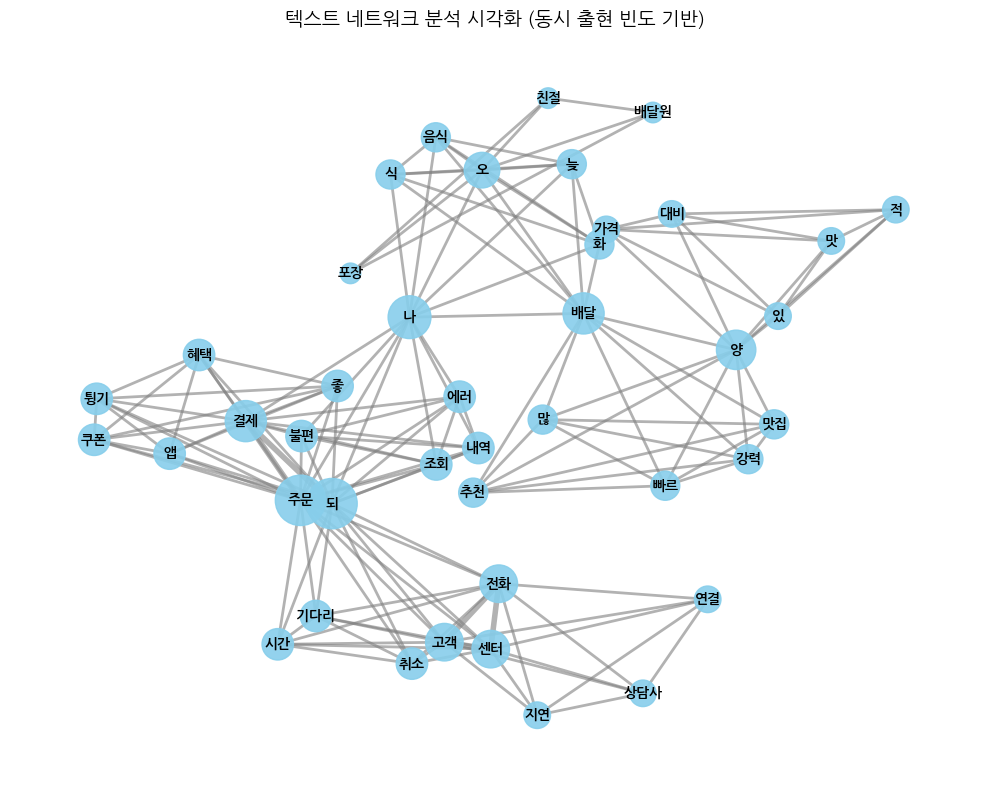

In [5]:
plt.figure(figsize=(10, 8), dpi=100)

# 레이아웃 설정 (Spring Layout)
pos = nx.spring_layout(G, k=0.8, seed=42)

# 1. 노드 크기 설정 (연결 중심성을 기반으로 동적 설정)
node_sizes = [degree_centrality[node] * 3000 for node in G.nodes()]

# 2. 에지 두께 설정 (가중치를 기반으로 설정)
edges = G.edges(data=True)
edge_widths = [d['weight'] * 2 for u, v, d in edges]

# 그리기
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.9)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray', alpha=0.6)
nx.draw_networkx_labels(G, pos, font_family=plt.rcParams['font.family'], font_size=10, font_weight='bold')

plt.title("텍스트 네트워크 분석 시각화 (동시 출현 빈도 기반)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

## 3. 머신러닝 기반 한국어 감성 분석 (Sentiment Analysis)

Naver Movie Sentiment Corpus(NSMC) 데이터셋을 활용해 데이터의 신뢰성 검증(Pandera)부터 감성 분류 모델 설계까지 진행합니다.

### 3.1 데이터 로드 및 Pandera 기반 스키마 검증

데이터가 손상되거나 비정상적인 포맷을 갖지 않았는지 `Pandera`의 `DataFrameSchema`를 사용해 사전에 유효성 검증을 진행합니다.

In [6]:
# NSMC 데이터셋 로드
train_df = pd.read_csv(CONTENT_DIR / 'ratings_train.txt', sep='\t')
test_df = pd.read_csv(CONTENT_DIR / 'ratings_test.txt', sep='\t')

print(f"학습용 데이터 크기: {train_df.shape}")
print(f"평가용 데이터 크기: {test_df.shape}")
display(train_df.head())

# Pandera 검증 스키마 정의
nsmc_schema = pa.DataFrameSchema(
    columns={
        "id": pa.Column(int, nullable=False, unique=True, required=True),
        "document": pa.Column(str, nullable=True, required=True),  # 텍스트는 간혹 공백이나 결측치가 있을 수 있음
        "label": pa.Column(int, pa.Check.isin([0, 1]), nullable=False, required=True)  # 0: 부정, 1: 긍정
    },
    coerce=True,          # 필요한 경우 정의한 타입으로 자동 형변환 강제
    strict=False          # 스키마에 정의되지 않은 컬럼이 있더라도 오류를 내지 않고 허용
)

# 유효성 검증 실행
try:
    nsmc_schema.validate(train_df, lazy=True)
    print("Pandera 검증 성공: 학습용 데이터가 사전에 정의된 모든 스키마 기준에 부합합니다.")
except pa.errors.SchemaErrors as err:
    print("Pandera 검증 실패:")
    display(err.failure_cases)

학습용 데이터 크기: (150000, 3)
평가용 데이터 크기: (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


Pandera 검증 성공: 학습용 데이터가 사전에 정의된 모든 스키마 기준에 부합합니다.


### 3.2 데이터 전처리 및 토큰화

대용량 영화 데이터셋에 대한 속도와 품질을 고려하여 `Kiwi` 분석기를 이용해 전처리 및 토큰화를 수행합니다. 학습 효율성을 극대화하기 위해 명사, 동사, 형용사, 어근만 화이트리스트 필터링합니다.

In [7]:
# 결측치 제거 및 문자열 형변환 보장
train_df = train_df.dropna(subset=['document'])
test_df = test_df.dropna(subset=['document'])

# 리소스 절약을 위해 일부 샘플링 진행 (수업 진행 및 검증 속도 최적화를 위해 학습 10000개, 테스트 3000개 추출)
train_sample = train_df.sample(n=10000, random_state=42).reset_index(drop=True)
test_sample = test_df.sample(n=3000, random_state=42).reset_index(drop=True)

kiwi = Kiwi()
allowed_tags = {'NNG', 'NNP', 'XR', 'VV', 'VA'}

def kiwi_tokenizer(text):
    # 정규식 1차 클렌징
    text = re.sub(r'[^가-힣\s]', '', str(text))
    tokens = kiwi.tokenize(text)
    return [t.form for t in tokens if t.tag in allowed_tags]

### 3.3 TF-IDF 기반 특징 추출 (Vectorization)

토큰화된 텍스트를 수치적 행렬로 변환합니다. 학습용 텍스트만 피팅하고, 테스트용은 변환만 적용합니다.

In [8]:
# TF-IDF 벡터라이저 정의
tfidf = TfidfVectorizer(tokenizer=kiwi_tokenizer, min_df=3, max_df=0.9, ngram_range=(1, 2))

print("TF-IDF 특징 추출 시작 (시간이 다소 소요될 수 있습니다)... ")
X_train_tfidf = tfidf.fit_transform(train_sample['document'])
X_test_tfidf = tfidf.transform(test_sample['document'])

y_train = train_sample['label']
y_test = test_sample['label']

print(f"X_train 형태: {X_train_tfidf.shape}")
print(f"X_test 형태: {X_test_tfidf.shape}")

TF-IDF 특징 추출 시작 (시간이 다소 소요될 수 있습니다)... 


X_train 형태: (10000, 4867)
X_test 형태: (3000, 4867)


### 3.4 모델 학습 및 평가 (Logistic Regression vs LightGBM)

전형적인 텍스트 분류 최적의 베이스라인인 로지스틱 회귀 모델과 트리 기반 앙상블인 LightGBM 모델의 성능을 비교합니다.

In [9]:
# 1. Logistic Regression 모델 학습
lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# 2. Logistic Regression 평가
lr_preds = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(y_test, lr_preds)
print(f"[Logistic Regression] 검증 정확도: {lr_accuracy:.4f}")
print(classification_report(y_test, lr_preds))

# 3. LightGBM 모델 학습
# TF-IDF 희소 행렬에 대응하기 위해 float32 형식으로 명시적 캐스팅 적용
X_train_lgb = X_train_tfidf.astype(np.float32)
X_test_lgb = X_test_tfidf.astype(np.float32)

lgb_model = lgb.LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train_lgb, y_train)

# 4. LightGBM 평가
lgb_preds = lgb_model.predict(X_test_lgb)
lgb_accuracy = accuracy_score(y_test, lgb_preds)
print(f"[LightGBM] 검증 정확도: {lgb_accuracy:.4f}")
print(classification_report(y_test, lgb_preds))

[Logistic Regression] 검증 정확도: 0.7913
              precision    recall  f1-score   support

           0       0.77      0.83      0.80      1514
           1       0.82      0.75      0.78      1486

    accuracy                           0.79      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.79      0.79      3000



[LightGBM] 검증 정확도: 0.7543
              precision    recall  f1-score   support

           0       0.74      0.80      0.77      1514
           1       0.78      0.71      0.74      1486

    accuracy                           0.75      3000
   macro avg       0.76      0.75      0.75      3000
weighted avg       0.76      0.75      0.75      3000



### 3.5 혼동 행렬 시각화

예측 오차가 어떻게 주로 발생하는지 Confusion Matrix를 그려서 패턴을 관찰합니다.

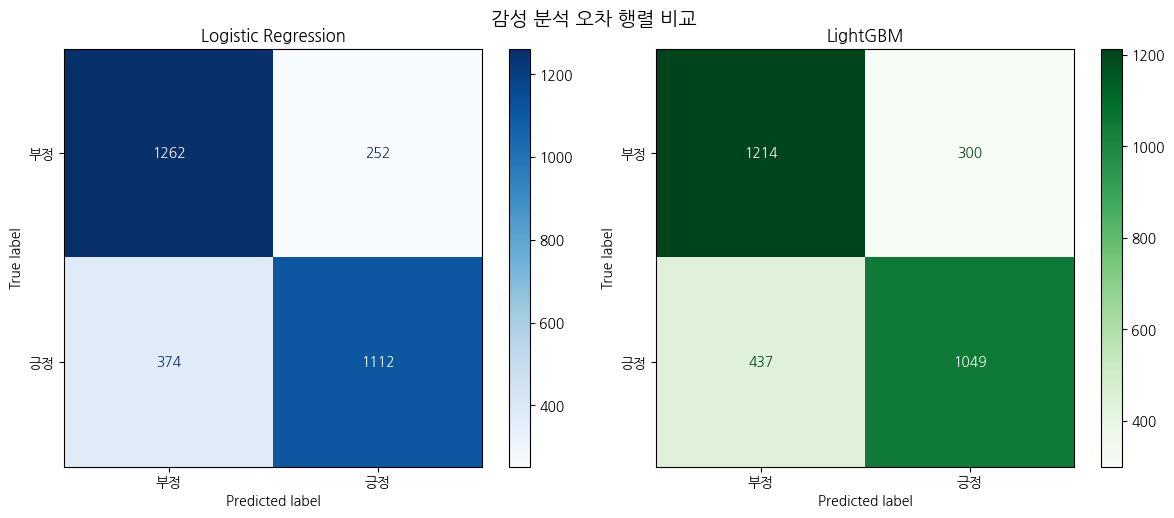

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_preds)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['부정', '긍정'])
disp_lr.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title("Logistic Regression")

# LightGBM Confusion Matrix
cm_lgb = confusion_matrix(y_test, lgb_preds)
disp_lgb = ConfusionMatrixDisplay(confusion_matrix=cm_lgb, display_labels=['부정', '긍정'])
disp_lgb.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title("LightGBM")

plt.suptitle("감성 분석 오차 행렬 비교", fontsize=14)
plt.tight_layout()
plt.show()

## 4. 실무 비즈니스 응용: 배달의민족 리뷰 감성 예측 및 핵심 불만 키워드 분석

NSMC 데이터로 검증된 감성 분석 모델을 실제 서비스 중인 **배달의민족 리뷰 데이터셋**에 적용하여 비즈니스 가치가 높은 인사이트를 연계 추출합니다.

In [11]:
# 배달의민족 리뷰 로드
baemin_df = pd.read_csv(CONTENT_DIR / '배달의민족댓글.csv')
print(f"배민 댓글 데이터 행 크기: {baemin_df.shape}")
display(baemin_df.head())

# 결측치 정제 및 텍스트 벡터화
baemin_df = baemin_df.dropna(subset=['댓글'])
X_baemin_tfidf = tfidf.transform(baemin_df['댓글'])

# 성능이 더 높은 Logistic Regression 모델로 리뷰 감성 스코어 및 긍/부정 라벨링 예측
# predict_proba를 사용해 긍정 확률(Sentiment Score) 산출
proba_scores = lr_model.predict_proba(X_baemin_tfidf)
baemin_df['sentiment_score'] = proba_scores[:, 1]  # 긍정 클래스(1)의 확률값
baemin_df['predicted_sentiment'] = lr_model.predict(X_baemin_tfidf)

# 결과 요약 출력
sentiment_counts = baemin_df['predicted_sentiment'].value_counts()
print(f"긍정 예측 리뷰: {sentiment_counts.get(1, 0)}건 ({sentiment_counts.get(1, 0)/len(baemin_df)*100:.1f}%)")
print(f"부정 예측 리뷰: {sentiment_counts.get(0, 0)}건 ({sentiment_counts.get(0, 0)/len(baemin_df)*100:.1f}%)")

# 극단적인 긍정/부정 리뷰 예시 추출
print("\n--- [최고점 긍정 리뷰 예시 Top 3] ---")
for idx, row in baemin_df.sort_values(by='sentiment_score', ascending=False).head(3).iterrows():
    print(f"[Score: {row['sentiment_score']:.3f}] {row['댓글']}")
    
print("\n--- [최저점 부정 리뷰 예시 Top 3] ---")
for idx, row in baemin_df.sort_values(by='sentiment_score', ascending=True).head(3).iterrows():
    print(f"[Score: {row['sentiment_score']:.3f}] {row['댓글']}")

배민 댓글 데이터 행 크기: (463, 2)


,Unnamed: 0,댓글
0,0,NaN
1,1,NaN
2,2,NaN
3,3,80분 걸린다길래 주문취소 하려고 주문내역에 들어가면 계속 최신 정보를 불러오지 못...
4,4,음식 하나 시키는데 우리나라 앱들은 1) 국내 번호 필요함. 번호 인증 필수 2) ...


긍정 예측 리뷰: 93건 (20.2%)
부정 예측 리뷰: 367건 (79.8%)

--- [최고점 긍정 리뷰 예시 Top 3] ---
[Score: 0.894] 메인 카테고리에 플라스틱 용기를 사용하지 않는 매장, 비건식단을 포함한 매장을 조회할 수 있는 카테고리가 생기면 좋겠어요. 플라스틱 포장재를 이용하지 않으려고 하는데 그런 매장을 일일히 찾기가 어렵습니다. 제로웨이스트와 채식을 지향하는 이용자가 많아지고 있으니 진지하게 고려해봐주시면 좋겠습니다. 음식점 입장에서도 전략적으로 노출기회를 얻을 수 있으니 좋을 것 같습니다.
[Score: 0.832] 주문하기 란에서 음식메뉴 어떤거 주문했는지 볼수 있었으면 좋겠습니다 가끔 제대로 주문했나 뒤로 가서 확인할때가 있어서
[Score: 0.828] 다른 앱보다 먹을곳 찾는게 더 많고 쉬워서 배고플때 시키기 딱 좋네여~^^

--- [최저점 부정 리뷰 예시 Top 3] ---
[Score: 0.018] 배달시간 맞은 적 한번도 없고 개짜증남. 알뜰배달은 왜 만든거임? 배달원 배정도 안되어서 음식 조리 다된 채 30분 보내고,, 요기요는 항상 시간 내에 오거나 더 빨리옴...진짜 배달 품질 업계 중 최악.
[Score: 0.038] 단연코 배달 플랫폼 중 최악. 배민을 쓸거면 절대 배민1을 쓰면 안됩니다. 라이저를 배민 쪽에서 배차해주는 시스템인데 그렇다보니 가게는 조리가 끝났는데 배차가 안 잡히면 가게와 고객은 무조건 기다리기만 해야합니다. 가게는 책임이 없으니 손놓고 있고 당연히 모든 피해는 고객만. 예전에는 정해진 시간내에 배달되지 않고 지연되면 몇천원 쿠폰이라도 주며 보상이라고 생색을 냈지만, 문제가 너무 자주 발생했는지 시스템을 몰래 바꿨습니다. 바로 도착 예정 시간이 몰래 슬금슬금 뒤로 밀리도록 만들어서 어쨋든 예정 시간내에는 도착했으니 책임이 없다는 식으로. 고객센터는 먹통이라 연결이 되려면 20~30분은 기본. 배민1 몇천원 할인에 낚이지 마시고 어차피 돈쓰는거 맛있게 제시간에 받을 수 있도록 다른 서

### 4.1 부정 리뷰 내 핵심 불만 단어 Semantic Network 구축

비즈니스 개선에서 가장 중요하게 들여다봐야 할 **부정적인 피드백(감성 스코어 < 0.3)**만 필터링하여, 사용자들이 어떤 맥락에서 불만을 동시에 제기하고 있는지 시각적으로 매핑합니다.

부정 분석 대상 리뷰 개수: 226개


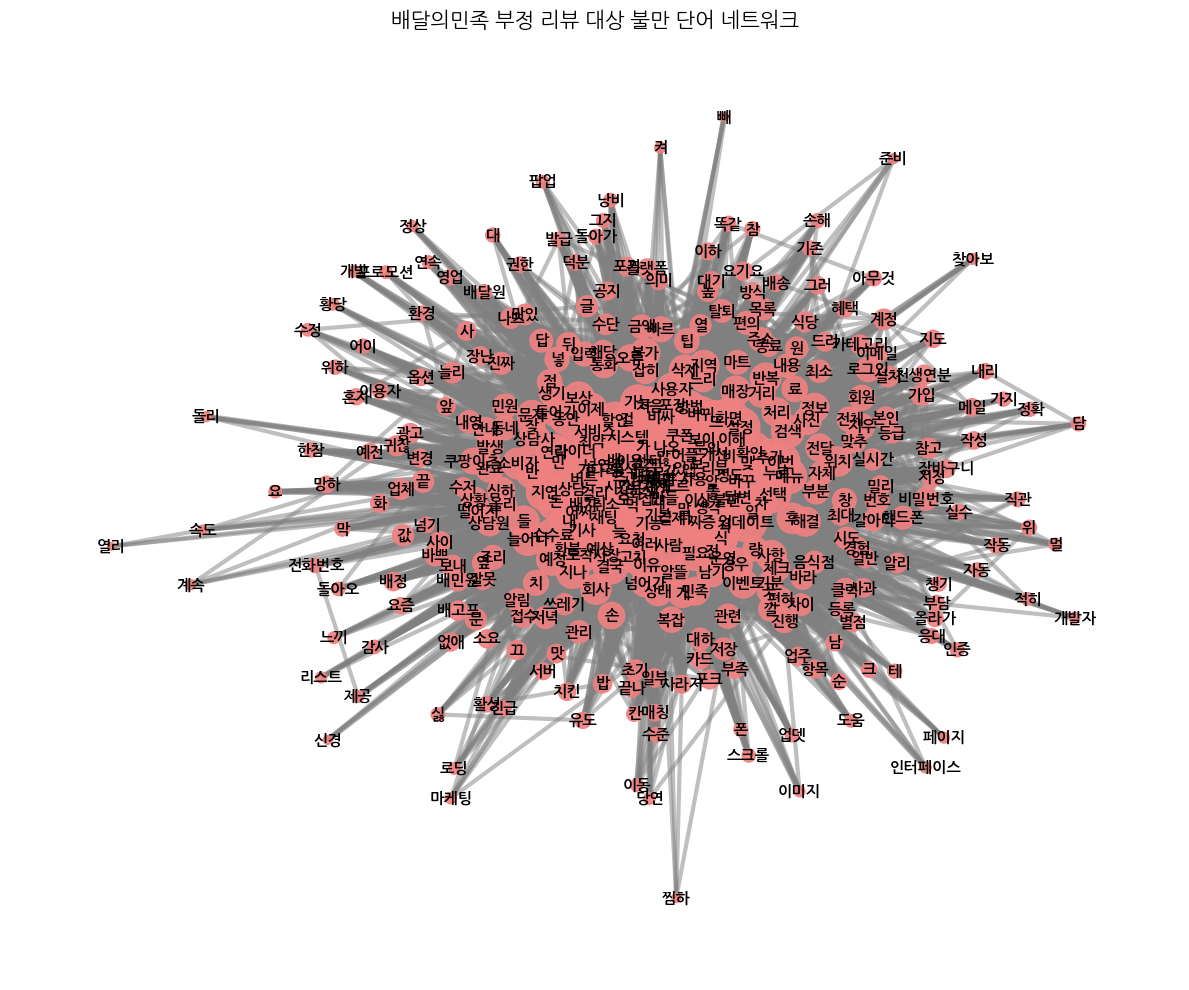

In [12]:
# 감성 지수 0.3 이하의 부정 리뷰 추출
negative_reviews = baemin_df[baemin_df['sentiment_score'] < 0.3]['댓글'].tolist()
print(f"부정 분석 대상 리뷰 개수: {len(negative_reviews)}개")

# 동시 출현 매트릭스 재구성
neg_co_occurrence = Counter()
neg_word_frequency = Counter()

for review in negative_reviews:
    words = extract_keywords(review)
    unique_words = sorted(list(set(words)))
    
    for w in unique_words:
        neg_word_frequency[w] += 1
        
    for w1, w2 in combinations(unique_words, 2):
        neg_co_occurrence[(w1, w2)] += 1

# 노드 및 에지 필터링 (가독성 향상을 위해 너무 빈도가 낮거나 불필요한 단어 제거)
min_node_freq = 3  # 최소 3번 등장 단어만 노드로 활용
min_edge_weight = 2  # 최소 2번 이상 동시 출현 단어 쌍만 에지로 연결

G_neg = nx.Graph()
for word, freq in neg_word_frequency.items():
    if freq >= min_node_freq:
        G_neg.add_node(word, size=freq)

for (w1, w2), count in neg_co_occurrence.items():
    if count >= min_edge_weight:
        # 노드가 필터링을 통과한 경우에만 에지 등록
        if G_neg.has_node(w1) and G_neg.has_node(w2):
            G_neg.add_edge(w1, w2, weight=count)

# 연결 중심성 및 시각화
neg_degree_centrality = nx.degree_centrality(G_neg)

plt.figure(figsize=(12, 10), dpi=100)
pos_neg = nx.spring_layout(G_neg, k=0.7, seed=42)

neg_node_sizes = [neg_degree_centrality[node] * 4000 for node in G_neg.nodes()]
neg_edge_widths = [d['weight'] * 1.5 for u, v, d in G_neg.edges(data=True)]

nx.draw_networkx_nodes(G_neg, pos_neg, node_size=neg_node_sizes, node_color='lightcoral', alpha=0.9)
nx.draw_networkx_edges(G_neg, pos_neg, width=neg_edge_widths, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G_neg, pos_neg, font_family=plt.rcParams['font.family'], font_size=11, font_weight='bold')

plt.title("배달의민족 부정 리뷰 대상 불만 단어 네트워크", fontsize=15)
plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
df = pd.read_csv(CONTENT_DIR / 'appreply.csv')

# 데이터 전처리
df.dropna(inplace=True)
df.reset_index(inplace=True)
df.drop(['index', 'Unnamed: 0'], axis=1, inplace=True)
df = df.drop_duplicates(subset=['text'])

noun_result = []

for temp in tqdm(df['text']):
    temp_result = re.sub(r'[^ㄱ-ㅣ가-힣\s]', '', temp)

    okt = Okt()

    temp_nouns = okt.nouns(temp_result)

    temp_nouns_result = [x for x in temp_nouns if len(x) > 1]

    noun_result.append(temp_nouns_result)

print(noun_result)

  0%|          | 0/1000 [00:00<?, ?it/s]


100%|██████████| 1000/1000 [00:12<00:00, 82.52it/s]

[['배달', '민족', '주문', '리뷰', '자주', '참고', '편입', '한가지', '건의', '사항', '최신', '점순', '주문', '자하', '메뉴', '메뉴', '리뷰', '확인', '기능', '메뉴', '검색', '기능', '리뷰', '특정', '메뉴', '검색', '기능', '주문', '수가', '메뉴', '리뷰', '보기', '위해', '래그', '시간', '소요', '효율', '발생', '긍정', '검토', '주심'], ['주문', '과거', '목록', '검색', '기능', '분명', '가게', '기억', '찾기', '메뉴', '검색', '곱창', '치면', '과거', '곱창', '목록', '가게', '리뷰', '리뷰', '보기'], ['검색', '화면', '전체', '배달', '포장', '배달', '크롤', '아래', '크롤', '자꾸만', '왼쪽', '오른쪽', '전체', '포장', '정말', '검색', '배달', '포장', '마트', '하나', '선택', '좌우', '가끔', '크롤', '왼쪽', '전체', '가게'], ['배달', '정렬', '가게', '가장', '위로', '지역', '추가', '배달', '별도', '체크', '배달', '만원', '이상', '배달', '장난', '하나', '하나', '가격', '대별', '금액', '체크', '배달', '별도', '확인'], ['최근', '업데이트', '안드로이드', '사양', '정도', '배민', '어플', '실행', '업데이트', '하라', '업데이트', '업데이트', '진행', '열기', '열기', '업데이트', '무한', '반복', '삭제', '설치', '환경설정', '증상', '다른', '증상', '이번', '업데이트', '관련', '파일', '확인', '참고', '사양', '핸드폰', '사양', '문제', '이번', '업데이트'], ['매장', '구분', '대체', '언제', '이면', '개선', '독점', '해이', '건가', '결제', '관련', '부분', '정말',

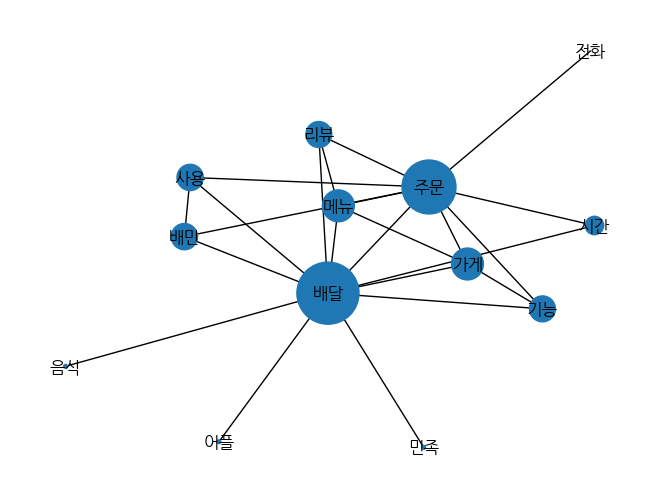

In [18]:
# Apriori 알고리즘 적용
result = list(apriori(noun_result,
                      min_support=0.05))

df = pd.DataFrame(result)

# 각 item 열의 길이를 저장할 리스트
item_len=[]

for temp in df['items']:
    item_len.append(len(temp))

# 새로운 열에 각 리스트의 길이 저장
df['length'] = item_len
df = df[(df['length']==2)&(df['support'] >= 0.06)]

G = nx.Graph()

ar = df['items']
G.add_edges_from(ar)

pr = nx.pagerank(G)

nsize = np.array([temp for temp in pr.values()])
nsize = 2000 * (nsize - min(nsize)) / (max(nsize) - min(nsize))

pos = nx.kamada_kawai_layout(G)

plt.rc('font', family='NanumGothic')

nx.draw(G,
        node_size=nsize,
        with_labels=True,
        font_family='NanumGothic'
         )
plt.show()

In [23]:
train_df = pd.read_csv(CONTENT_DIR / 'ratings_train.txt', sep='\t')

# 댓글 결측치를 빈칸으로 처리
train_df = train_df.fillna(' ')
result = []
for temp in train_df['document']:
    kor_str = re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣\s]', '', temp)
    result.append(kor_str)
train_df['document'] = train_df['document'].apply(lambda x : re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣\s]', '', x) )

test_df = pd.read_csv(CONTENT_DIR / 'ratings_test.txt', sep='\t')
test_df = test_df.fillna(' ')
test_df['document'] = test_df['document'].apply(lambda x : re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣\s]', '', x))

train_df.drop('id', axis=1, inplace=True)
test_df.drop('id', axis=1, inplace=True)

okt = Okt()

def okt_tokenizer(text):
    token_kor = okt.morphs(text)
    return token_kor

# TF-IDF 벡터라이저 정의
tfidf = TfidfVectorizer(tokenizer=okt_tokenizer, min_df=3, max_df=0.9, ngram_range=(1, 2))

print("TF-IDF 특징 추출 시작 (시간이 다소 소요될 수 있습니다)... ")
X_train_tfidf = tfidf.fit_transform(train_df['document'])
X_test_tfidf = tfidf.transform(test_df['document'])

y_train = train_df['label']
y_test = test_df['label']

print(f"X_train 형태: {X_train_tfidf.shape}")
print(f"X_test 형태: {X_test_tfidf.shape}")

TF-IDF 특징 추출 시작 (시간이 다소 소요될 수 있습니다)... 
X_train 형태: (150000, 115612)
X_test 형태: (50000, 115612)


In [26]:
# 1. Logistic Regression 모델 학습
lr_model = LogisticRegression(C=3.5, max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# 2. Logistic Regression 평가
lr_preds = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(y_test, lr_preds)
print(f"[Logistic Regression] 검증 정확도: {lr_accuracy:.4f}")
print(classification_report(y_test, lr_preds))

[Logistic Regression] 검증 정확도: 0.8572
              precision    recall  f1-score   support

           0       0.85      0.86      0.86     24827
           1       0.86      0.85      0.86     25173

    accuracy                           0.86     50000
   macro avg       0.86      0.86      0.86     50000
weighted avg       0.86      0.86      0.86     50000



=== 감성 분석 결과 요약 ===
sentiment
True     68
False    31
Name: count, dtype: int64
------------------------------
sentiment
True     68.686869
False    31.313131
Name: proportion, dtype: float64


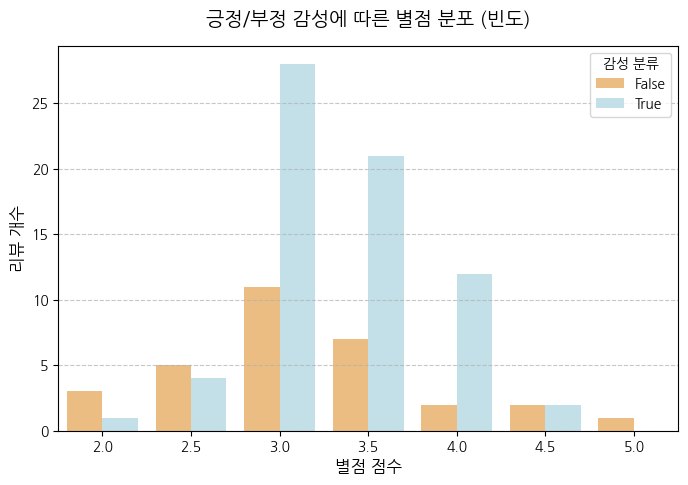

In [61]:
# 사용자 입력 리뷰에 대한 감성 분석 함수
def pred_sentiment(review):
    # 1. 데이터 클리닝
    review = re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣\s]', '', review)

    # 2. Tf-idf 변환
    tfidf_review = tfidf.transform([review])

    # 3. 감성 예측
    prediction = lr_model.predict(tfidf_review)[0]

    # 4. 결과 반환(1:긍정, 0: 부정)
    return prediction == 1

movie_reviews_list = [
    ("백룸", 4.0, "기억과 마음이라는 공간에 대한 뛰어난 시각적 상상력과 정서적 응집력."),
    ("로메리아", 3.5, "창작자에겐 반드시 만들어야 넘어갈 수 있는 이야기가 있다."),
    ("너바나 더 밴드", 3.5, "떠들썩하고 유쾌한 활력이 영화 안팎을 내내 넘나든다."),
    ("군체", 3.0, "완전한 소통이라는 지옥, 하나가 된 전체라는 악마."),
    ("마이클", 2.5, "그 모든 흥분에도 기이할 정도로 영화적 야심과 시각이 결여되어 있다."),
    ("교생실습", 3.0, "“개연성은 묻지마”와 “신파는 안돼”를 호기롭게 외치며 직진하는 엉뚱한 세계의 맛."),
    ("그녀가 돌아온 날", 3.5, "탁월한 예술가가 30년간 걸어가서 생긴 길을 서성이며 태도와 구조라는 말을 계속 떠올렸다."),
    ("르누아르", 3.5, "죽어가는 세계를 마른 눈으로 바라볼 때 맺히는 유년의 멍울."),
    ("새벽의 Tango", 2.5, "제자리를 맴돌며 그저 춤춘다."),
    ("관념의 남자 김철수", 2.0, "뒤로 뛰는 재치."),
    ("힌드의 목소리", 3.5, "조마조마한 마음으로, 끓어오르는 분노로."),
    ("침묵의 친구", 3.5, "존재의 울타리를 넘어서는 생명의 명상."),
    ("미야자키 하야오의 그대들은 어떻게 살 것인가", 3.5, "허구와 현실, 죽음과 삶의 경계를 문지를 때 미야자키 하야오의 세계에서 일어나는 일들."),
    ("살목지", 2.5, "점프 스케어를 헌 칼처럼 쓴다."),
    ("위 리브 인 타임", 3.0, "쿨한 캐릭터가 눈물나는 이야기 속으로 들어갈 때."),
    ("두 검사", 5.0, "요소마다 두 차례 반복하며 감옥을 지어 올리는 연출이 드러내는 섬뜩한 순환의 미로."),
    ("사랑, 우유, 그리고 치즈", 3.0, "공간과 정서가 젊음의 생기로 밀착되어 있다."),
    ("프로젝트 헤일메리", 3.5, "과학적 사고 자체가 즐거움의 원천이 되고 인물의 성격 자체가 공감의 바탕이 된다."),
    ("드림스", 3.0, "이 모든 게 다 널 사랑해서 그런 거야,라는 지독한 속박의 말."),
    ("극장의 시간들", 3.0, "극장에서 보냈던 그 많은 시간들을 애틋하고 뿌듯하게 호출한다."),
    ("아르코", 3.0, "우정과 사랑은 날개를 달아 시간도 뛰어넘는다는 소담한 동화."),
    ("노 어더 랜드", 3.5, "폭압에 저항하는 우정의 카메라가 남긴 착잡한 배음."),
    ("다이 마이 러브", 3.5, "굳이 이해를 요청하지 않은 채 어머니/아내의 우울이 내지르는 파열음이 내내 절박하다."),
    ("호퍼스", 3.0, "날카롭고 복잡한 이야기를 유쾌하고 포근하게 다룬다."),
    ("매드 댄스 오피스", 3.0, "생존에서 삶으로 이끄는 댄스의 다정한 스텝."),
    ("브라이드!", 2.5, "크리처 창조 과정에서 활용하지 못한 부위들이 제각각 널려 있는 수술실을 엿보는 듯하다."),
    ("햄넷", 4.0, "하염없이 뻗어오는 그 손들에 이마를 맡길 때 마침내 다시 시간이 흐른다."),
    ("28년 후: 뼈의 사원", 3.5, "약해서 악해진 자들의 지옥."),
    ("렌탈 패밀리: 가족을 빌려드립니다", 3.5, "인간과 문화에 대한 예의와 존중으로 그윽하다."),
    ("슬라이드 스트럼 뮤트", 2.5, "촉각을 클로즈업 쇼트들에 새기는 방식이 도드라진다."),
    ("판결", 2.0, "장르와 감성의 피상적인 이식."),
    ("센티멘탈 밸류", 4.5, "예술의 닫힌 문 뒤에서 나의 이야기로 사무쳐오는 것들."),
    ("넘버원", 2.0, "설정에 나포된 서사의 맥없는 표류."),
    ("폭풍의 언덕", 4.0, "상처에 파고들어 고통으로 기어이 꽃을 피우는 미친 사랑의 노래."),
    ("휴민트", 3.0, "다채롭고 또렷한 액션신들이 고전적인 정조에 담겼다."),
    ("허밍", 3.0, "‘더 이상’과 ‘여전히’ 사이에서 나지막이 떠돌다 문득 흘러내리는 것들."),
    ("왕과 사는 남자", 3.0, "끝내 마음 깊은 곳의 현을 제대로 울린다."),
    ("직장상사 길들이기", 3.5, "장르와 설정에 대한 예측과 기대를 가지고 노는 샘 레이미의 추력."),
    ("두 번째 계절", 3.0, "설명을 묻은 자리에 무성하게 돋아난 시간의 표정들."),
    ("대디오", 3.0, "단 두 사람의 목소리와 눈빛만으로 내내 팽팽하다."),
    ("시라트", 4.0, "이미지의 이명과 사운드의 잔상 속에서 펄럭이는 섬뜩한 춤 혹은 몸부림."),
    ("리틀 아멜리", 3.5, "천진한 망상과 아릿한 서정이 빚은 유년의 생."),
    ("광장", 3.0, "동토에 고요히 흩날리는 겨울의 순애."),
    ("굿 포 낫씽", 3.0, "시작을 걷는 영화의 팽팽한 동력."),
    ("마이 선샤인", 3.0, "그때는 몰랐던 성장이 여리고 부드럽게 원을 그린다."),
    ("어리석은 자는 누구인가", 3.0, "범죄영화 장르의 능숙한 진행에 인간의 숨결을 더했다."),
    ("만약에 우리", 3.0, "만약에의 간절함이 결국엔의 한숨으로 흩어질 때 밀려드는 애상."),
    ("누벨바그", 4.0, "영화사의 폭발적인 순간이 낭만과 덕력으로 내내 찰랑거린다."),
    ("파더 마더 시스터 브라더", 3.5, "“한 가족의 내부에 없었던 사람은 그 가족 중 누가 어떤 어려움을 겪을지 말할 수 없다.” (‘엠마’, 제인 오스틴)"),
    ("슈퍼 해피 포에버", 3.0, "추억을 생물처럼 다룬다."),
    ("척의 일생", 3.0, "끝이 다가온다 해도 마지막 춤을 출 순 있잖아, 이 아름다웠던 세상에서."),
    ("대홍수", 2.5, "착점이 솔깃하지만 장르의 전환을 설득해내지 못한다."),
    ("사운드 오브 폴링", 4.0, "공간의 눅진한 기억을 카메라는 어떻게 깁는가."),
    ("고스트라이트", 3.5, "몸으로 살아내야 이해할 수 있는 슬픔이 있다."),
    ("아바타: 불과 재", 3.0, "제자리를 활보하면서 여전히 놀라게 만드는 괴력."),
    ("여행과 나날", 4.5, "말에서 벗어난 이미지가 여로에서 감촉해낸 자그마한 평화."),
    ("바늘을 든 소녀", 4.0, "우회할 수 없었던 이야기에 끼얹어진 뒤틀린 초상."),
    ("더 러닝 맨", 2.5, "에드거 라이트를 보러 갔다가 요란한 미래 활극 한 편을 보고 나왔다."),
    ("한란", 2.5, "잊지 말아야 할 역사적 비극에 대한 평면적 서술."),
    ("넌센스", 3.0, "믿고 싶은 것 어느새 믿어버린 것 믿었다고 생각한 것 사이에서 기묘하고도 집요하게."),
    ("주토피아 2", 3.5, "잘 닦인 길 위로 다시금 사랑스럽고 유쾌하고 곧게 뻗어 나간다."),
    ("윗집 사람들", 3.0, "흥미로운 영화는 흥미로운 사람들이 만든다."),
    ("국보", 4.0, "인생보다 큰 예술과 세계보다 중한 무대의 아름다움이 아찔하고도 허허롭게."),
    ("콘티넨탈 '25", 3.5, "정의와 위선 사이의 크레바스에 빠진 어떤 문명의 파산."),
    ("위키드: 포 굿", 3.0, "최적 캐스팅의 힘이 끝까지 유지된다."),
    ("맨홀", 3.0, "메울 수 없는 구멍의 아이러니 속에 웅크린 자의 표상."),
    ("왼손잡이 소녀", 3.5, "공간과 삶의 관계를 생생하게 포착한다."),
    ("럭키 데이 인 파리", 3.0, "그저 우연이라며 잠시 어깨를 으쓱하고 지나가는 자의 지혜 혹은 탄식."),
    ("부고ニア", 3.5, "서슬 퍼렇게 마침표를 찍는 자의 미소."),
    ("에스퍼의 빛", 3.0, "빛이 있으라 하시니 갈래를 따라 절로 흐르기 시작하는 마음들."),
    ("너와 나의 5분", 3.0, "개성에 대한 의구심을 감성으로 넘어선다."),
    ("바얌섬", 3.5, "시간의 꼬리를 물고 구비구비 돌아가는 꿈결 같은 만담과 인생."),
    ("베일리와 버드", 3.0, "이미지에 날개를 다는 영국 팝의 스킨십."),
    ("프랑켄슈타인", 4.5, "참혹한 아름다움이 가슴을 저민다."),
    ("세계의 주인", 4.0, "함부로 명명하거나 헤집는 대신 온전히 맡기고 보듬는 연출의 넓고 깊은 품."),
    ("양양", 3.0, "지워진 이야기를 되찾고 사라진 이름을 다시 새기는 카메라."),
    ("굿뉴스", 4.0, "이런 한국영화가 나오기를 애타게 기다렸다."),
    ("만남의 집", 3.0, "때론 연민으로 충분하다."),
    ("사람과 고기", 3.0, "얼마든지 처절할 수 있는 이야기를 끝내 힘이 나는 슬픔과 웃음으로."),
    ("극장판 체인소 맨: 레제편", 3.5, "물과 불과 태풍으로 낭자한 피투성이 순정."),
    ("원 배틀 애프터 어나더", 4.5, "시대가 요구하는 영화를 누구도 예상하지 못하는 방식으로 신랄하고도 장대하게."),
    ("그저 사고였을 뿐", 4.0, "등을 타고 기어오르는 폭압의 사라지지 않는 이명."),
    ("미러 넘버 3", 3.5, "물러서지 않고서 떠나보내는 상실에 대하여."),
    ("어쩔수가없다", 4.0, "어쩔 수 없다고 내세우는 자들이 만들어낸 실낙원의 통렬한 순환."),
    ("파르테노페", 2.5, "압도적인 아름다움과 원초적인 그리움에 대한 화려하고 따분한 소고."),
    ("얼굴", 3.0, "한 움큼씩 챙긴 모두가 외면하려 했지만 결국 명확히 들여다봐야 하는 그 유산의 민낯."),
    ("비밀일 수밖에", 3.0, "어머니와 아들 사이의 정말 살갑고 뭉클한 순간들."),
    ("3학년 2학기", 3.5, "장면마다 또렷이 음각되어 있는 노동영화의 살과 뼈."),
    ("3670", 3.0, "역동적으로 관계를 포착하고 세밀하게 감정을 응시한다."),
    ("부재", 3.0, "공간에 고이거나 흐르는 삶의 자취를 가만가만 짚는다."),
    ("너는 나를 불태워", 4.0, "텍스트의 거품 속에서 뒹굴며 배우는 영화의 몸."),
    ("다른 것으로 알려질 뿐이지", 3.5, "어긋나고 바뀌고 빗나가고 미끄러지는 일상의 파편들이 시적으로 안온하다."),
    ("내 말 좀 들어줘", 4.0, "폭포 같은 말과 사막 같은 침묵 사이로 흐르는 삶의 어두운 강물을 들여다보면."),
    ("아임 스틸 히어", 3.5, "결국 미소와 품위를 잃지 않는 자가 끝내 지치지 않는다."),
    ("극장판 귀멸의 칼날: 무한성편", 3.5, "한계를 뛰어넘은 듯 다가오는 액션들이 구조적 결함까지 넘어서 질주한다."),
    ("어글리 시스터", 3.0, "일단 떠올린 착상을 지옥 끝까지 밀고 간다."),
    ("악마가 이사왔다", 2.0, "장편 한 편을 완성하기 위해 필요한 에너지와 아이디어가 모두 부족하다."),
    ("여름정원", 3.5, "죽음을 보려 하면 내내 삶이 보인다."),
    ("수연의 선율", 3.0, "아이의 마음을 떠올리며 조마조마하다가 아득해진다.")
]

# 1. 튜플 리스트를 DataFrame으로 변환하면서 영문 컬럼명을 지정합니다.
df = pd.DataFrame(movie_reviews_list, columns=['title', 'rating', 'comment'])

# 2. 'comment' 컬럼에 감성 분석 함수를 적용하여 'sentiment' 컬럼으로 추가합니다.
df['sentiment'] = df['comment'].apply(pred_sentiment)

# 결과 확인
print("=== 감성 분석 결과 요약 ===")
print(df['sentiment'].value_counts())
print("-" * 30)
print(df['sentiment'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
# x축은 별점 점수, hue(범례)는 긍/부정 감성
sns.countplot(x='rating', hue='sentiment', data=df, palette='RdYlBu')
plt.title('긍정/부정 감성에 따른 별점 분포 (빈도)', fontsize=14, pad=15)
plt.xlabel('별점 점수', fontsize=12)
plt.ylabel('리뷰 개수', fontsize=12)
plt.legend(title='감성 분류')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [63]:
# 별점은 4.0 이상인데 부정(False)으로 분류된 리뷰 추출
misclassified = df[(df['rating'] >= 4.0) & (df['sentiment'] == False)]

print(f"별점 4.0 이상 중 오분류된 건수: {len(misclassified)}건")
print("-" * 50)

# 실제 예측 확률값(Probability)과 텍스트를 출력하여 원인 파악
# (참고: 함수 내에서 predict_proba의 긍정 확률을 반환하도록 수정해서 볼 수 있습니다.)
for idx, row in misclassified.head(10).iterrows():
    print(f"[별점: {row['rating']}] {row['comment']}")


별점 4.0 이상 중 오분류된 건수: 5건
--------------------------------------------------
[별점: 5.0] 요소마다 두 차례 반복하며 감옥을 지어 올리는 연출이 드러내는 섬뜩한 순환의 미로.
[별점: 4.5] 말에서 벗어난 이미지가 여로에서 감촉해낸 자그마한 평화.
[별점: 4.0] 이런 한국영화가 나오기를 애타게 기다렸다.
[별점: 4.5] 시대가 요구하는 영화를 누구도 예상하지 못하는 방식으로 신랄하고도 장대하게.
[별점: 4.0] 텍스트의 거품 속에서 뒹굴며 배우는 영화의 몸.


In [10]:
import asyncio
from playwright.async_api import async_playwright
import pandas as pd

async def crawl_playstore_reviews_fast(app_id="com.dki.spb_android", max_reviews=50):
    url = f"https://play.google.com/store/apps/details?id={app_id}&hl=ko&gl=KR"
    
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(
            user_agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
        )
        page = await context.new_page()

        # [네트워크 속도 향상] 이미지, 폰트, 미디어 차단 (CSS는 레이아웃 붕괴 방지를 위해 허용)
        async def block_resources(route):
            if route.request.resource_type in ["image", "font", "media"]:
                await route.abort()
            else:
                await route.continue_()
        
        await page.route("**/*", block_resources)

        print(f"[{app_id}] 앱 페이지 접속 중...")
        await page.goto(url)

        # 1. '리뷰 모두 보기' 클릭
        try:
            await page.evaluate("window.scrollTo(0, document.body.scrollHeight / 2);")
            await page.wait_for_timeout(1000)
            
            review_btn = page.get_by_role("button", name="리뷰 모두 보기").first
            await review_btn.click()
            await page.wait_for_selector('div[role="dialog"]')
            print("리뷰 팝업 진입 완료.")
        except Exception as e:
            print("리뷰 버튼 클릭 실패:", e)
            await browser.close()
            return None

        # 2. 팝업창 무한 스크롤 (리소스가 차단되어 페이지 로딩이 매우 빠르므로 1.5초 대기)
        dialog_selector = 'div[role="dialog"]'
        last_height = 0
        patience = 0
        
        while True:
            current_count = await page.locator('div.RHo1pe').count()
            print(f"현재 로드된 리뷰 개수: {current_count}개 / 목표: {max_reviews}개")
            
            if current_count >= max_reviews:
                break

            # 스크롤 내리기
            await page.evaluate(
                f"document.querySelector('{dialog_selector}').querySelector('div:nth-child(2)').scrollTo(0, 10000000);"
            )
            await page.wait_for_timeout(1500) 

            new_height = await page.evaluate(
                f"document.querySelector('{dialog_selector}').querySelector('div:nth-child(2)').scrollHeight"
            )
            if new_height == last_height:
                patience += 1
                if patience > 3:
                    break
            else:
                patience = 0
                last_height = new_height

        # 3. [일괄 데이터 추출] textContent와 수정된 클래스(X5PpBb, h3YV2d) 적용
        print("데이터 일괄 추출 중...")
        reviews_data = await page.evaluate("""
            (maxCount) => {
                const cards = document.querySelectorAll('div.RHo1pe');
                const result = [];
                const limit = Math.min(cards.length, maxCount);
                
                for (let i = 0; i < limit; i++) {
                    const card = cards[i];
                    
                    // X5PpBb 로 수정 반영
                    const author = card.querySelector('div.X5PpBb')?.textContent || "";
                    
                    // 별점 추출
                    const ratingLabel = card.querySelector('div[aria-label*="별표"]')?.getAttribute('aria-label') || "";
                    let rating = null;
                    if (ratingLabel.includes('개 만점에')) {
                        const parts = ratingLabel.split('개 만점에');
                        if (parts.length > 1) {
                            rating = parseInt(parts[1].split('개')[0].trim());
                        }
                    }
                    
                    // 날짜 및 h3YV2d 로 수정 반영
                    const date = card.querySelector('span.bp9Aid')?.textContent || "";
                    const content = card.querySelector('div.h3YV2d')?.textContent || "";
                    
                    result.push({ author, rating, date, content });
                }
                return result;
            }
        """, max_reviews)

        await browser.close()
        
    df = pd.DataFrame(reviews_data)
    df.to_csv("따릉이_리뷰_고속.csv", index=False, encoding="utf-8-sig")
    print(f"크롤링 완료! 총 {len(df)}개의 리뷰를 '따릉이_리뷰_고속.csv' 파일로 저장했습니다.")
    return df


In [13]:
import pandas as pd
from google_play_scraper import Sort, reviews

def crawl_large_reviews(app_id="com.dki.spb_android", target_count=100000):
    all_reviews = []
    continuation_token = None
    
    print(f"[{app_id}] API 기반 대용량 리뷰 수집을 시작합니다. 목표 건수: {target_count}개")
    
    while len(all_reviews) < target_count:
        # 한번 호출할 때 최대 1,000개씩 끊어서 수집 (가장 안정적)
        result, continuation_token = reviews(
            app_id,
            lang='ko',            # 한국어 리뷰
            country='kr',         # 한국 지역
            sort=Sort.NEWEST,     # 최신순 정렬 (Sort.MOST_RELEVANT로 관련성 순 정렬 가능)
            count=1000,
            continuation_token=continuation_token
        )
        
        if not result:
            print("더 이상 가져올 리뷰가 없습니다.")
            break
            
        all_reviews.extend(result)
        print(f"현재 수집 완료: {len(all_reviews)}개...")
        
        # 구글 서버 차단 방지를 위한 짧은 휴식 (중요)
        import time
        time.sleep(1.0)
        
        # continuation_token이 없으면 끝까지 다 긁은 것임
        if not continuation_token:
            break
            
    # 데이터 가공 및 저장
    df = pd.DataFrame(all_reviews)
    
    # 필요한 컬럼만 추출 및 이름 매핑
    df_clean = df[['userName', 'score', 'at', 'content']]
    df_clean.columns = ['author', 'rating', 'date', 'content']
    
    df_clean.to_csv("따릉이_대용량_리뷰.csv", index=False, encoding="utf-8-sig")
    print(f"최종 완료! 총 {len(df_clean)}개의 리뷰를 '따릉이_대용량_리뷰.csv'에 저장했습니다.")


In [15]:
crawl_large_reviews(target_count=100000)

[com.dki.spb_android] API 기반 대용량 리뷰 수집을 시작합니다. 목표 건수: 100000개
현재 수집 완료: 1000개...
현재 수집 완료: 2000개...
현재 수집 완료: 3000개...
현재 수집 완료: 4000개...
현재 수집 완료: 5000개...
현재 수집 완료: 6000개...
현재 수집 완료: 7000개...
현재 수집 완료: 8000개...
현재 수집 완료: 9000개...
현재 수집 완료: 9385개...
더 이상 가져올 리뷰가 없습니다.
최종 완료! 총 9385개의 리뷰를 '따릉이_대용량_리뷰.csv'에 저장했습니다.
